# Appointments vs. Staffing

- Analyze the relationship between the number of primary care appointments per head of population in sub-ICBs within SNEE (Suffolk and North East Essex) and staffing levels per head of population. The goal is to use the GP Patient list, the most recent appointments dataset, and the staffing dataset from NHSE (all currently available in the catalog) to investigate how the patient-to-GP ratio correlates with appointments per head specifically in the context of SNEE compared to broader English sub-ICBs.

Exam question/Objective:

- Determine if staffing levels per head of population significantly affect the number of primary care appointments per head in sub-ICBs within SNEE. Additionally, assess whether the patient-to-GP ratio in SNEE reflects or deviates from the trends seen in other English sub-ICBs.

Stakeholder Request:

- I want a report that details the relationship between the number of primary care appointments per head of population and staffing levels per head of population in sub-ICBs within SNEE. The report should highlight if variations in patient-to-GP ratios contribute to differences in appointments per head and whether these findings are consistent with or diverge from other English sub-ICBs.

Key Data Sources:
- GP Patient list from NHSE
- Most recent appointments dataset from NHSE
- Staffing dataset from NHSE

Methodology/Approach:

- Data extraction from NHSE catalog for GP Patient list, appointments data, and staffing data.
- Clean and preprocess the datasets to ensure consistency.
- Calculate patient-to-GP ratios and staffing levels per head of population.
- Conduct initial exploratory data analysis (EDA) to understand distribution and correlations.
- Apply statistical analysis (e.g., linear regression or correlation analysis) to assess relationships.
- Compare results between SNEE sub-ICBs and other English sub-ICBs.
- Visualize findings through charts and graphs.
- Summarize insights in a report.

## Library Imports

In [1]:
import os
from pathlib import Path
if 'notebooks' in str(Path.cwd()):
    os.chdir('..')

# Library imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from matplotlib.ticker import FuncFormatter
import datetime as dt
import pickle
from typing import Dict
from time import sleep
from datetime import timedelta
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr

# project imports from src
from src.schemas import DataCatalog
from src.various_methods import PlotCounter, get_workingdays
from src import constants

# Importing SNEE styles
from sneeifstyles import mpl_style
mpl_style()

import warnings
warnings.filterwarnings("ignore")

## Initial Set-up

In [2]:
## Constants
SNEE_SUB_ICB = ['06L','06T','07K']
SNEE_SUB_ICB_NAMES = ['Ipswich & East Suffolk', 'North East Essex', 'West Suffolk']
NOTEBOOK_ALIAS = "Appointments"
GP_PATIENTS_LIST_CATALOG = 'Patients Registered at a GP practice, September 2024'
GP_APPOINTMENTS_CATALOG_NAME:str = 'Appointments in General Practice, August 2024' # 1 year of appointments aug/23 - aug/24
GP_WORKFORCE_CATALOG:str = 'General Practice workforce'  # August/2024
GP_LIST_AGE_BANDS = constants.GP_LIST_AGE_BANDS 
GP_LIST_AGE_LABELS = constants.GP_LIST_AGE_LABELS 
SNEE_SUBICB_CODES = list(constants.ONS_CODES.keys())

# EU Standard Population weights
eu_standard_population = {'0_4': 5000, '5_9': 5500, '10_14': 5500, '15_19': 5500, '20_24': 6000, '25_29': 6000, '30_34': 6500, '35_39': 7000, '40_44': 7000,
    '45_49': 7000,'50_54': 7000,'55_59': 6500,'60_64': 6000,'65_69': 5500,'70_74': 5000,'75_79': 4000,'80_84': 2500,'85_89': 1500,'90+': 1000
}


# Loading the Data Catalog
catalog =  DataCatalog.load_from_yaml("data_catalog.yaml")

# Initializing the plotCounter object
plot_counter = PlotCounter(name=NOTEBOOK_ALIAS)

# set up output directories
for i in ['outputs/assumptions', 'outputs/plots', 'outputs/tables']:
    if not os.path.exists(i):
        os.makedirs(i)

## 1. GP list Loading and processing

In [3]:
def process_gp_list(df):
    """
    Args:
        df (pandas.DataFrame): GP LIST DataFrame. 
    Returns:
        pandas.DataFrame: 
    """
    df_ = df.copy()
    
    # REMOVING the total population both 'AGE_GROUP_5' and 'SEX' columns are 'ALL'
    df_ = df.loc[(df['AGE_GROUP_5'] != 'ALL') & (df['SEX'] != 'ALL')]
    
    # Filter rows to keep only those with ORG_TYPE as 'SUB_ICB_LOCATION_CODE'
    df_ = df_[df_['ORG_TYPE'].isin(['SUB_ICB_LOCATION_CODE'])].copy()
    
    df_ = df_.rename(columns={'ORG_CODE':'SUB_ICB_CODE'})

    # Dropping unused columns
    df_ = df_.drop(columns=['ONS_CODE','PUBLICATION','EXTRACT_DATE','ORG_TYPE','SEX','POSTCODE']).reset_index(drop=True)
    
    # Converting 90-95 and 95+ into single age band
    df_['AGE_GROUP_5'] = df_['AGE_GROUP_5'].replace({'90_94':'90+', '95+':'90+'})
    
    #
    df_ = df_.groupby(['SUB_ICB_CODE','AGE_GROUP_5']).sum().reset_index()
  
    return df_

In [4]:
gp_list_df = catalog.get_catalog_entry_by_name(GP_PATIENTS_LIST_CATALOG)
patients_df = gp_list_df.load()

# calculating total populatin to be merged later
population = patients_df[['ORG_CODE','SEX','AGE_GROUP_5','NUMBER_OF_PATIENTS']]
population = population.loc[(patients_df['AGE_GROUP_5'] == 'ALL') & (patients_df['SEX'] == 'ALL')].drop(columns=['SEX','AGE_GROUP_5']).rename(columns={'NUMBER_OF_PATIENTS':'Total_pop'})

patients_df = process_gp_list(patients_df)
# Merging the total population to calculate standardised rates
patients_df = pd.merge(patients_df, population, left_on='SUB_ICB_CODE', right_on='ORG_CODE', how='left').drop(columns={'ORG_CODE'})

patients_df.tail()

,SUB_ICB_CODE,AGE_GROUP_5,NUMBER_OF_PATIENTS,Total_pop
2009,X2C4Y,70_74,19188,461152
2010,X2C4Y,75_79,17870,461152
2011,X2C4Y,80_84,10796,461152
2012,X2C4Y,85_89,6555,461152
2013,X2C4Y,90+,3389,461152


In [ ]:
# Add EU Standard Population weights to the DataFrame
patients_df['standard_pop'] = patients_df['AGE_GROUP_5'].map(eu_standard_population)

# Calculate crude rate
patients_df['crude_rate'] = patients_df['NUMBER_OF_PATIENTS'] / patients_df['Total_pop']

# Calculate crude rate
patients_df['Std_patients_per_100k'] = (patients_df['crude_rate'] * patients_df['standard_pop']).round(2)

patients_df.tail()

,SUB_ICB_CODE,AGE_GROUP_5,NUMBER_OF_PATIENTS,Total_pop,standard_pop,crude_rate,Std_patients_per_100k
2009,X2C4Y,70_74,19188,461152,5000,0.041609,208.04
2010,X2C4Y,75_79,17870,461152,4000,0.038751,155.00
2011,X2C4Y,80_84,10796,461152,2500,0.023411,58.53
2012,X2C4Y,85_89,6555,461152,1500,0.014214,21.32
2013,X2C4Y,90+,3389,461152,1000,0.007349,7.35


## 2. Workforce Loading and processing

In [7]:
def process_workforce(df):
    """
    Args:
        df (pandas.DataFrame): Workforce DataFrame. 
    Returns:
        pandas.DataFrame: 
    """
    df_ = df.copy()
    
    # Dropping unused columns
    df_ = df_.drop(columns=['YEAR','Month','COMM_REGION_CODE','COMM_REGION_NAME','ICB_CODE','ICB_NAME','SUB_ICB_NAME','DATA_SOURCE','UNIQUE_IDENTIFIER','DETAILED_STAFF_ROLE',
                            'STAFF_ROLE','COUNTRY_QUALIFICATION_AREA','COUNTRY_QUALIFICATION_GROUP','AGE_BAND','AGE_YEARS','GENDER'])
    
    # Group by sub-icb and staff type
    df_ = df_.groupby(['SUB_ICB_CODE', 'STAFF_GROUP']).sum().round(2).reset_index()

    return df_

In [8]:
workforce_entry =  catalog.get_catalog_entry_by_name(GP_WORKFORCE_CATALOG)
workforce_df = workforce_entry.load()

# To match the names of icbs at the end
col = ['ICB_CODE','ICB_NAME','SUB_ICB_CODE','SUB_ICB_NAME']
icb_name_code_match = workforce_df[col].drop_duplicates().reset_index(drop=True)
icb_name_code_match['ICB_NAME']  = icb_name_code_match['ICB_NAME'].str.replace('^NHS | ICB', '', regex=True)
icb_name_code_match['SUB_ICB_NAME']  = icb_name_code_match['SUB_ICB_NAME'].str.replace('^NHS | ICB', '', regex=True)

workforce_df = process_workforce(workforce_df)
workforce_df.tail()

,SUB_ICB_CODE,STAFF_GROUP,FTE
420,W2U3Z,Nurses,374.31
421,X2C4Y,Admin/Non-Clinical,536.59
422,X2C4Y,Direct Patient Care,111.65
423,X2C4Y,GP,248.59
424,X2C4Y,Nurses,113.16


## 3. Appointments Loading and processing (keeping 1 full year of appointments)

In [9]:
def process_appointments(df):
    """
    Args:
        df (pandas.DataFrame): Appointments DataFrame. 
    Returns:
        pandas.DataFrame: 
    """
    df_ = df.copy()
    
    # Convert the 'date_column' to datetime format
    df_['Appointment_Date'] = pd.to_datetime(df_['Appointment_Date'], format='%d%b%Y')

    # Calculate the date one year before the latest date
    one_year_ago = (df_['Appointment_Date'].max()) - timedelta(days=365)

    # Filter the DataFrame to get data from the last year
    df_ = df_[df_['Appointment_Date'] >= one_year_ago].reset_index(drop=True)
    
    # Dropping unused columns
    df_ = df_.drop(columns=['SUB_ICB_LOCATION_ONS_CODE','SUB_ICB_LOCATION_NAME','ICB_ONS_CODE','REGION_ONS_CODE','ACTUAL_DURATION'])
    
    # Group by 'SUB_ICB_LOCATION_CODE', and sum 'COUNT_OF_APPOINTMENTS' 
    df_ = df_.groupby(['SUB_ICB_LOCATION_CODE'])['COUNT_OF_APPOINTMENTS'].sum().reset_index().rename(columns={'SUB_ICB_LOCATION_CODE' : 'SUB_ICB_CODE'})
    
    return df_

In [10]:
appointments_catalog_entry = catalog.get_catalog_entry_by_name(GP_APPOINTMENTS_CATALOG_NAME)
appointments_df = appointments_catalog_entry.load()
appointments_df = process_appointments(appointments_df)
appointments_df

,SUB_ICB_CODE,COUNT_OF_APPOINTMENTS
0,00L,2089082
1,00N,712275
2,00P,1447505
3,00Q,793575
4,00R,960248
...,...,...
101,D9Y0V,9312912
102,M1J4Y,5231051
103,M2L0M,2774435
104,W2U3Z,13897197


## 4. Merging the datasets and Calculating Ratios

In [9]:
# Adding all staff type FTE for a combined FTE
combined_fte_df = workforce_df.groupby(['SUB_ICB_CODE']).sum()

# Merging all the datasets together
appointments_vs_staffing_df = pd.merge(patients_df, appointments_df, on='SUB_ICB_CODE', how='inner')
appointments_vs_staffing_df = pd.merge(appointments_vs_staffing_df, workforce_df, on='SUB_ICB_CODE', how='right')
appointments_vs_staffing_df = pd.merge(appointments_vs_staffing_df, combined_fte_df, on='SUB_ICB_CODE', how='left').drop(columns=('STAFF_GROUP_y')).rename(columns=({'FTE_y':'Combined Staff FTE','FTE_x':'FTE','STAFF_GROUP_x' : 'STAFF_GROUP'}))

# Calculating Ratios
appointments_vs_staffing_df['Appointments_per_head'] = (appointments_vs_staffing_df['COUNT_OF_APPOINTMENTS'] / appointments_vs_staffing_df['NUMBER_OF_PATIENTS']).round(2)
# QUESTION --> adding FTE of all 4 staff group and divide that FTE by number of patients to get stafing per head ?
appointments_vs_staffing_df['Staffing_per_1k'] = ((appointments_vs_staffing_df['Combined Staff FTE'] / appointments_vs_staffing_df['NUMBER_OF_PATIENTS']) * 1000).round(2)
appointments_vs_staffing_df['Patient_to_gp_Ratio'] = (appointments_vs_staffing_df['NUMBER_OF_PATIENTS'] / appointments_vs_staffing_df['FTE']).round(2)

# Filtering STAFF_GROUP to only GP
appointments_vs_staffing_gp_df = appointments_vs_staffing_df[appointments_vs_staffing_df['STAFF_GROUP'] == 'GP'].dropna().reset_index(drop=True)
appointments_vs_staffing_gp_df.tail()

,SUB_ICB_CODE,ONS_CODE,NUMBER_OF_PATIENTS,COUNT_OF_APPOINTMENTS,STAFF_GROUP,FTE,Combined Staff FTE,Appointments_per_head,Staffing_per_1k,Patient_to_gp_Ratio
101,D9Y0V,E38000253,1730028.0,9312912.0,GP,1019.23,4116.73,5.38,2.38,1697.39
102,M1J4Y,E38000249,1140994.0,5231051.0,GP,527.11,2163.57,4.58,1.90,2164.62
103,M2L0M,E38000257,534870.0,2774435.0,GP,311.06,1316.62,5.19,2.46,1719.51
104,W2U3Z,E38000256,2899512.0,13897197.0,GP,1302.45,4630.87,4.79,1.60,2226.20
105,X2C4Y,E38000254,461152.0,2972654.0,GP,248.59,1009.99,6.45,2.19,1855.07


## 5. Determine relationship between: Staffing level VS. Primary care appointments (per head of population)

In [10]:
# Calculate national averages
national_avg_staffing = appointments_vs_staffing_gp_df['Staffing_per_1k'].mean()
national_avg_appointments = appointments_vs_staffing_gp_df['Appointments_per_head'].mean()
national_avg_patient_to_gp = appointments_vs_staffing_gp_df['Patient_to_gp_Ratio'].mean()

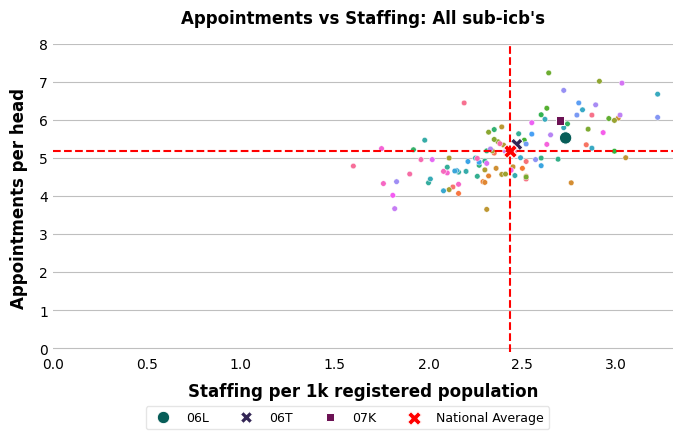

In [11]:
# Scatter plot: Appointments per head vs Staffing per head
plt.figure(figsize=(8, 4))
# Plotting all SUB-ICB's
sns.scatterplot(data=appointments_vs_staffing_gp_df, x='Staffing_per_1k', y='Appointments_per_head', hue='SUB_ICB_CODE', legend=False)
# Plotting SNEE SUB-ICB's
sns.scatterplot(data=appointments_vs_staffing_gp_df[appointments_vs_staffing_gp_df['SUB_ICB_CODE'].isin(SNEE_SUB_ICB)], x='Staffing_per_1k', y='Appointments_per_head', hue='SUB_ICB_CODE', style='SUB_ICB_CODE', s=80)
# Plotting National averages
sns.scatterplot(x=[national_avg_staffing], y=[national_avg_appointments], color='red', marker='X', s=100, label='National Average')
plt.axhline(y=national_avg_appointments, color='red', linestyle='--')
plt.axvline(x=national_avg_staffing, color='red', linestyle='--')
plt.title("Appointments vs Staffing: All sub-icb's")
plt.xlabel('Staffing per 1k registered population')
plt.ylabel('Appointments per head')
plt.legend(loc =(0.15,-0.25), ncol=4)
plt.ylim(-0.1,8)
plt.xlim(left=0)
plt.show()

In [12]:
# Correlation analysis
pearson_corr, pearson_p = pearsonr(appointments_vs_staffing_gp_df['Staffing_per_1k'], appointments_vs_staffing_gp_df['Appointments_per_head'])
print(f"Pearson Correlation: {pearson_corr}, P-value: {pearson_p}")

# Spearman correlation
spearman_corr, spearman_p = spearmanr(appointments_vs_staffing_gp_df['Staffing_per_1k'], appointments_vs_staffing_gp_df['Appointments_per_head'])
print(f"Spearman Correlation: {spearman_corr}, P-value: {spearman_p}")

Pearson Correlation: 0.6512384616332136, P-value: 4.0816549582491446e-14
Spearman Correlation: 0.6615031497819852, P-value: 1.1738998875395406e-14


**Interpretation:**  (Since the data seems to be linear, therefore more importance to Pearsons correlation)
- The correlation coefficient (0.6512) indicates a moderate to strong positive relationship between staffing levels per head and appointments per head. This suggests that, as staffing levels per head increase, there is a significant tendency for appointments per head to also increase. While the relationship is not perfectly linear, the association is meaningful and notable.
- The P-value (4.08e-14) is far below 0.05, confirming the correlation is statistically significant and rejecting the null hypothesis of no relationship.

In [13]:
# Regression analysis
X = appointments_vs_staffing_gp_df[['Staffing_per_1k']]  # Predictor
y = appointments_vs_staffing_gp_df['Appointments_per_head']  # Target
X = sm.add_constant(X)  # Add constant for intercept
model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     Appointments_per_head   R-squared:                       0.424
Model:                               OLS   Adj. R-squared:                  0.419
Method:                    Least Squares   F-statistic:                     76.59
Date:                   Tue, 19 Nov 2024   Prob (F-statistic):           4.08e-14
Time:                           14:40:27   Log-Likelihood:                -89.654
No. Observations:                    106   AIC:                             183.3
Df Residuals:                        104   BIC:                             188.6
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const       

- Intercept (const = 1.7352):
When Staffing_per_1k is zero, the model predicts Appointments_per_head to be 1.7352. While this scenario is unlikely in practice, it serves as the baseline for the model.

- Slope (1.4216):
For every one-unit increase in Staffing_per_1k, Appointments_per_head is predicted to increase by 1.4216 units.

- The slope is statistically significant with a p-value < 0.05, confirming that staffing levels significantly influence appointment levels.

The R-squared (0.424) indicates that approximately 42.4% of the variability in appointments per head is explained by staffing levels. This suggests a moderate relationship between the two variables.

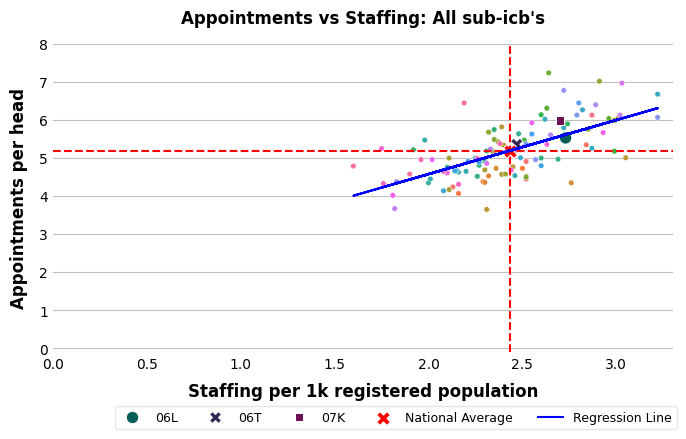

In [32]:
# Scatter plot: Appointments per head vs Staffing per head
plt.figure(figsize=(8, 4))
# Plotting all SUB-ICB's
sns.scatterplot(data=appointments_vs_staffing_gp_df, x='Staffing_per_1k', y='Appointments_per_head', hue='SUB_ICB_CODE', legend=False)
# Plotting SNEE SUB-ICB's
sns.scatterplot(data=appointments_vs_staffing_gp_df[appointments_vs_staffing_gp_df['SUB_ICB_CODE'].isin(SNEE_SUB_ICB)], x='Staffing_per_1k', y='Appointments_per_head', hue='SUB_ICB_CODE', style='SUB_ICB_CODE', s=80)
# Plotting National averages
sns.scatterplot(x=[national_avg_staffing], y=[national_avg_appointments], color='red', marker='X', s=100, label='National Average')
plt.axhline(y=national_avg_appointments, color='red', linestyle='--')
plt.axvline(x=national_avg_staffing, color='red', linestyle='--')

# Regression line
X = appointments_vs_staffing_gp_df[['Staffing_per_1k']]
X_const = sm.add_constant(X)  # Add constant for intercept
predicted = model.predict(X_const)
plt.plot(appointments_vs_staffing_gp_df['Staffing_per_1k'], predicted, color='blue', label='Regression Line')

plt.title("Appointments vs Staffing: All sub-icb's")
plt.xlabel('Staffing per 1k registered population')
plt.ylabel('Appointments per head')
plt.legend(loc =(0.1,-0.25), ncol=5)
plt.ylim(-0.1,8)
plt.xlim(left=0)
plt.show()

## 6. Determine relationship between: Patient to GP ratio VS. Primary care appointments (per head of population)

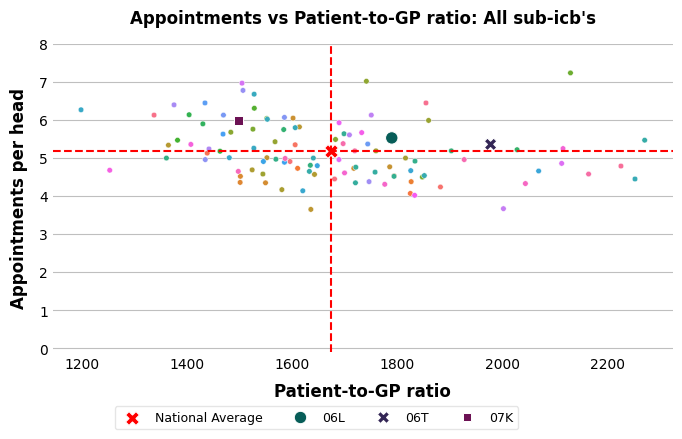

In [15]:
# Scatter plot: Appointments per head vs Patient to GP ratio
plt.figure(figsize=(8, 4))
# Plotting all SUB-ICB's
sns.scatterplot(data=appointments_vs_staffing_gp_df, x='Patient_to_gp_Ratio', y='Appointments_per_head', hue='SUB_ICB_CODE', legend=False)
# Plotting National averages
sns.scatterplot(x=[national_avg_patient_to_gp], y=[national_avg_appointments], color='red', marker='X', s=100, label='National Average')
# Plotting SNEE SUB-ICB's
sns.scatterplot(data=appointments_vs_staffing_gp_df[appointments_vs_staffing_gp_df['SUB_ICB_CODE'].isin(SNEE_SUB_ICB)], x='Patient_to_gp_Ratio', y='Appointments_per_head', hue='SUB_ICB_CODE', style='SUB_ICB_CODE', s=80)
plt.axhline(y=national_avg_appointments, color='red', linestyle='--')
plt.axvline(x=national_avg_patient_to_gp, color='red', linestyle='--')
plt.title("Appointments vs Patient-to-GP ratio: All sub-icb's")
plt.xlabel('Patient-to-GP ratio')
plt.ylabel('Appointments per head')
plt.legend(loc =(0.1,-0.25), ncol=4)
plt.ylim(-0.1,8)
plt.show()

In [16]:
# Correlation analysis
pearson_corr, pearson_p = pearsonr(appointments_vs_staffing_gp_df['Patient_to_gp_Ratio'], appointments_vs_staffing_gp_df['Appointments_per_head'])
print(f"Pearson Correlation: {pearson_corr}, P-value: {pearson_p}")

# Spearman correlation
spearman_corr, spearman_p = spearmanr(appointments_vs_staffing_gp_df['Patient_to_gp_Ratio'], appointments_vs_staffing_gp_df['Appointments_per_head'])
print(f"Spearman Correlation: {spearman_corr}, P-value: {spearman_p}")

Pearson Correlation: -0.2682067798155717, P-value: 0.005440267913120888
Spearman Correlation: -0.34032176070076914, P-value: 0.0003577370792953074


- Pearson Correlation indicates a weak negative linear correlation between Patient_to_gp_Ratio and Appointments_per_head
- while Spearmans correlation suggests a weak-to-moderate negative relationship between Patient_to_gp_Ratio and Appointments_per_head
- The p-value (< 0.05) suggests the correlation is statistically significant.

In [17]:
# Regression analysis
X = appointments_vs_staffing_gp_df[['Patient_to_gp_Ratio']]  # Predictor
y = appointments_vs_staffing_gp_df['Appointments_per_head']  # Target
X = sm.add_constant(X)  # Add constant for intercept
model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     Appointments_per_head   R-squared:                       0.072
Model:                               OLS   Adj. R-squared:                  0.063
Method:                    Least Squares   F-statistic:                     8.061
Date:                   Tue, 19 Nov 2024   Prob (F-statistic):            0.00544
Time:                           14:43:00   Log-Likelihood:                -114.95
No. Observations:                    106   AIC:                             233.9
Df Residuals:                        104   BIC:                             239.2
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
cons

- Coefficient for Patient_to_gp_Ratio (-0.0009): Indicates a small negative effect: For every unit increase in Patient_to_gp_Ratio, Appointments_per_head decreases by 0.0009 (holding other factors constant).
- There is a weak but statistically significant (due to p_val < 0.05) negative relationship between Patient_to_gp_Ratio and Appointments_per_head.
- While the relationship exists, the practical impact is negligible given the very small coefficient and low R-squared value.

## 7. Visualize results between ICB's & SUB-ICB's

### 7.1. Comparing ICB'S

In [20]:
appointments_vs_staffing_icb = pd.merge(appointments_vs_staffing_gp_df, icb_name_code_match, on='SUB_ICB_CODE', how='left').drop(columns=['SUB_ICB_CODE','ONS_CODE','NUMBER_OF_PATIENTS','COUNT_OF_APPOINTMENTS','STAFF_GROUP','FTE','ICB_CODE','SUB_ICB_NAME','Combined Staff FTE'])
appointments_vs_staffing_icb = appointments_vs_staffing_icb.groupby(['ICB_NAME']).mean().sort_values(by='Patient_to_gp_Ratio', ascending=False).round(2).reset_index()
appointments_vs_staffing_icb

,ICB_NAME,Appointments_per_head,Staffing_per_1k,Patient_to_gp_Ratio
0,North West London,4.79,1.60,2226.20
1,"Bedfordshire, Luton and Milton Keynes",4.58,1.90,2164.62
2,Kent and Medway,4.86,2.31,2113.38
3,North East London,4.33,1.76,2044.37
4,South East London,3.67,1.82,2002.54
5,Hampshire and Isle Of Wight,4.92,2.19,1975.18
6,Frimley,4.96,1.96,1927.86
7,Mid and South Essex,4.85,2.03,1924.45
8,"Buckinghamshire, Oxfordshire and Berkshire West",4.78,2.18,1845.43
9,North Central London,4.02,1.81,1833.53


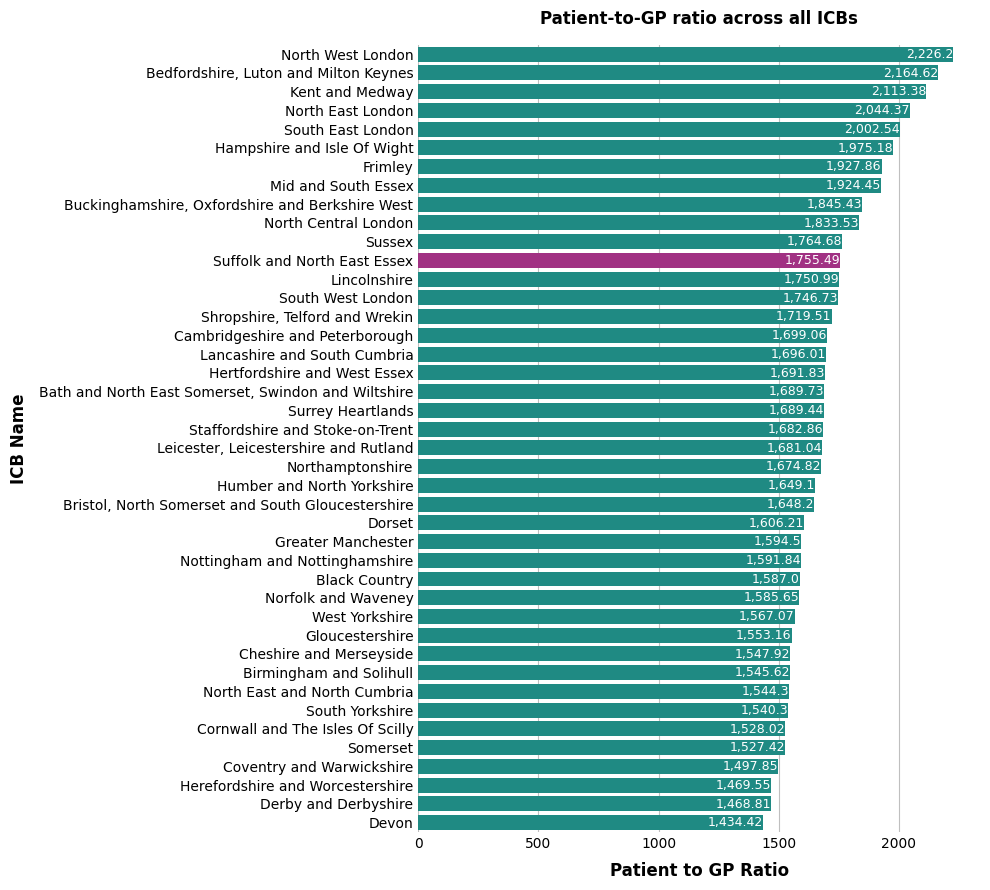

In [21]:
plt.figure(figsize=(10, 9))
sns.barplot(x='Patient_to_gp_Ratio', y='ICB_NAME', data=appointments_vs_staffing_icb.sort_values(by='Patient_to_gp_Ratio', ascending=False), color='#0d9c93')
# Highlighting SNEE ICB
sns.barplot(x='Patient_to_gp_Ratio', y='ICB_NAME', data=appointments_vs_staffing_icb[appointments_vs_staffing_icb['ICB_NAME'] == 'Suffolk and North East Essex'], color='#b41e8c')
plt.xlabel('Patient to GP Ratio', fontsize=12)
plt.xlabel('Patient to GP Ratio', fontsize=12)
plt.ylabel('ICB Name', fontsize=12)
plt.title('Patient-to-GP ratio across all ICBs')
plt.grid(axis='x')

for i, value in enumerate(appointments_vs_staffing_icb['Patient_to_gp_Ratio'].values):
    plt.text(value, i+0.2, f'{value:,}', ha='right', fontsize=9, color='white')
    
plt.tight_layout()
plt.show()

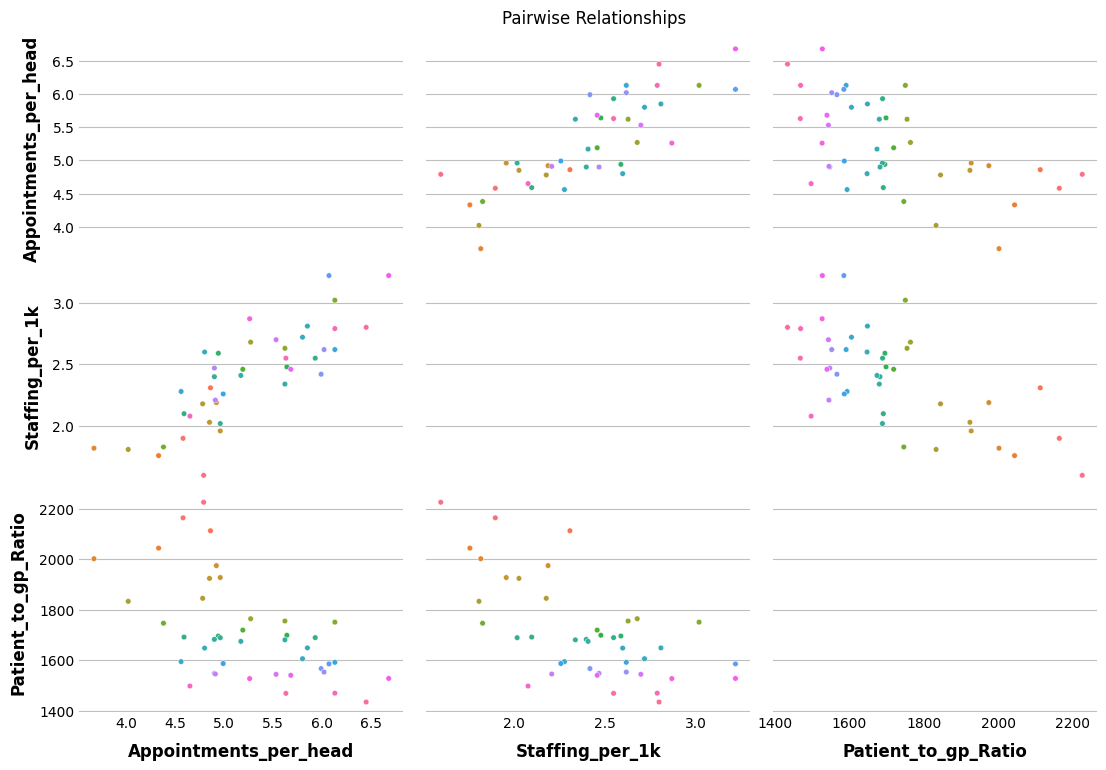

In [22]:
# Pairplot for pairwise relationships
pairplot = sns.pairplot(appointments_vs_staffing_icb, vars=['Appointments_per_head', 'Staffing_per_1k', 'Patient_to_gp_Ratio'], hue='ICB_NAME', diag_kind='kde', plot_kws={'legend': False}, aspect=1.5)
pairplot._legend.remove()
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

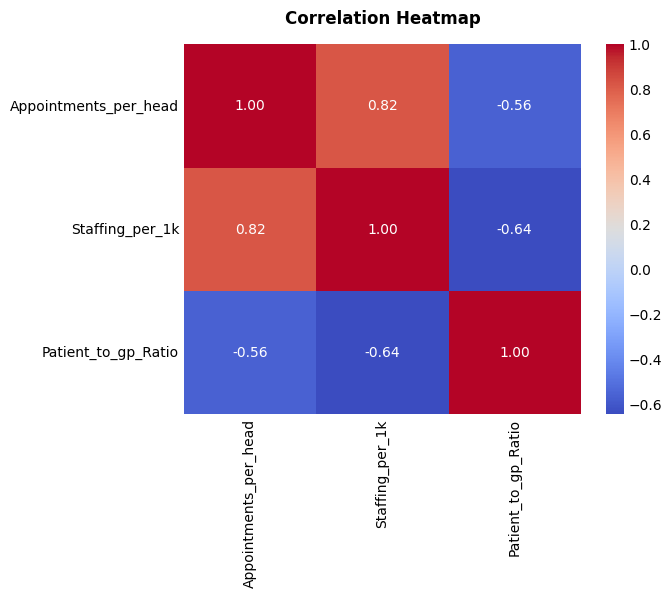

In [23]:
# Compute correlation matrix
corr = appointments_vs_staffing_icb[['Appointments_per_head', 'Staffing_per_1k', 'Patient_to_gp_Ratio']].corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 7.2. Comparing SUB-ICB's

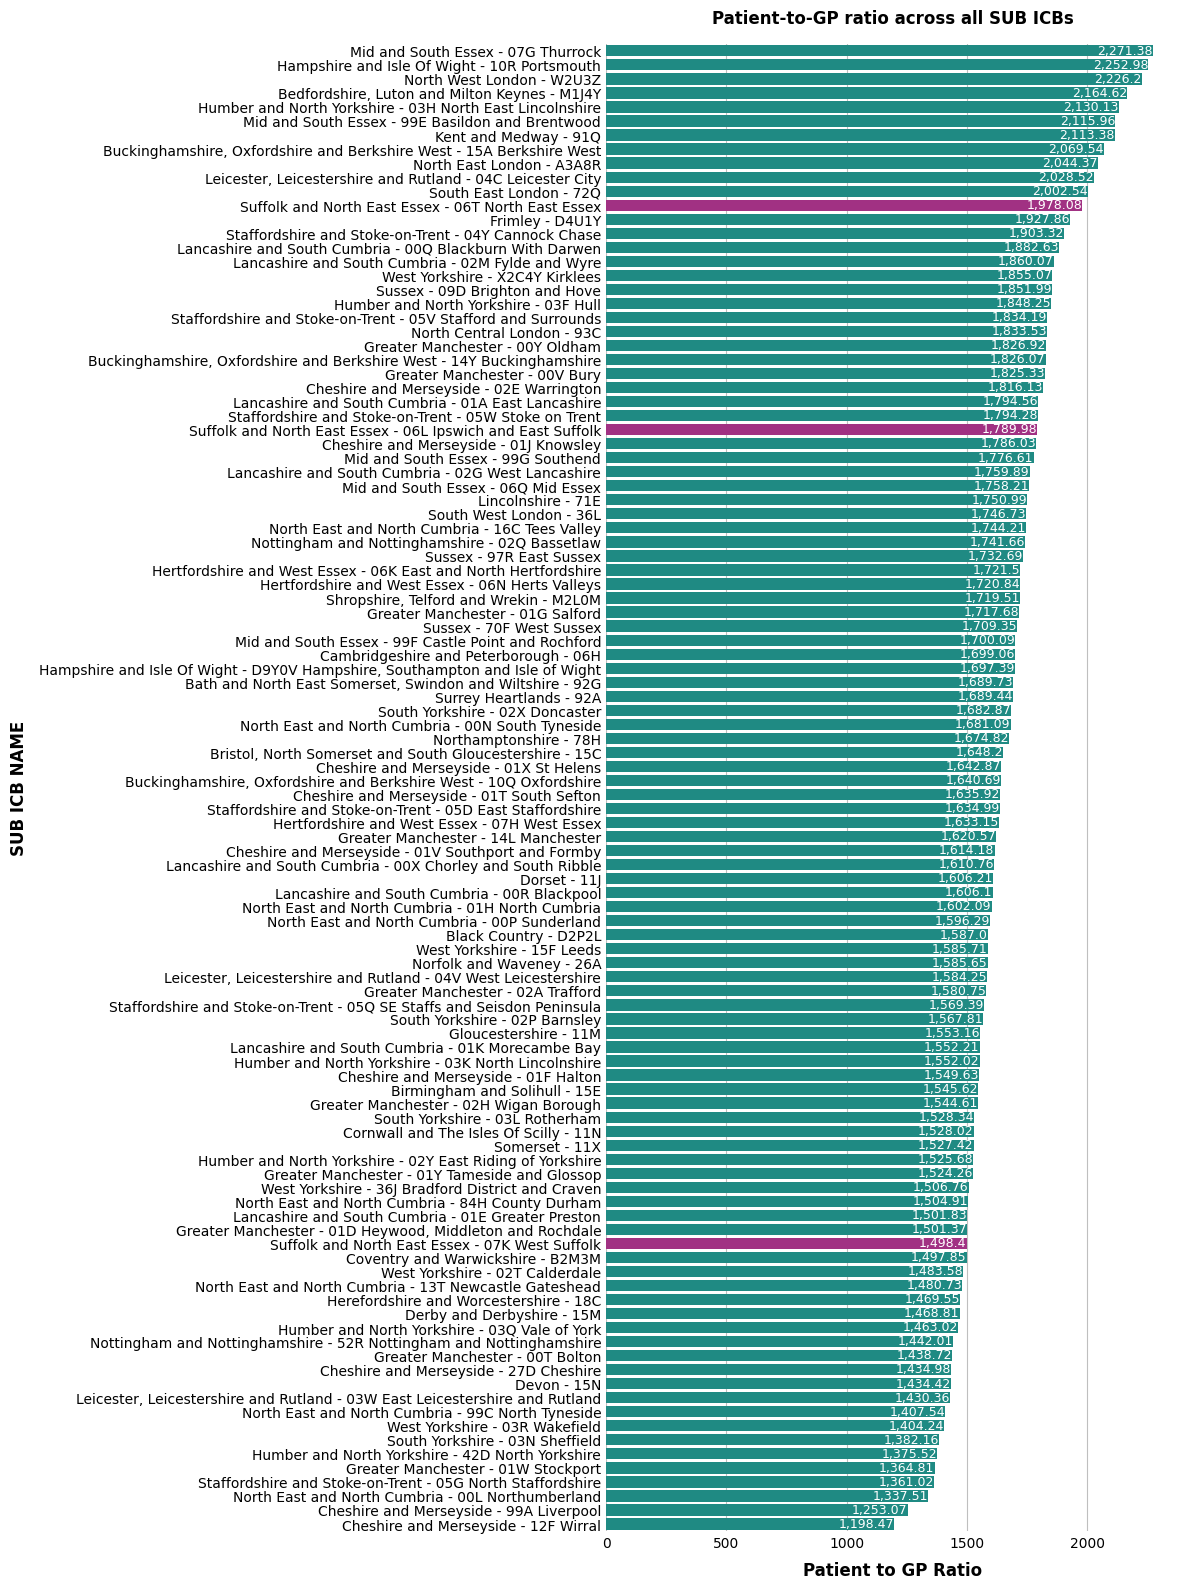

In [25]:
appointments_vs_staffing_sub_icb = pd.merge(appointments_vs_staffing_gp_df, icb_name_code_match, on='SUB_ICB_CODE', how='left').drop(columns=['SUB_ICB_CODE','ONS_CODE','NUMBER_OF_PATIENTS','COUNT_OF_APPOINTMENTS','STAFF_GROUP','FTE','ICB_CODE','ICB_NAME','Combined Staff FTE'])
appointments_vs_staffing_sub_icb = appointments_vs_staffing_sub_icb.sort_values(by='Patient_to_gp_Ratio', ascending=False)

plt.figure(figsize=(12, 16))
sns.barplot(x='Patient_to_gp_Ratio', y='SUB_ICB_NAME', data=appointments_vs_staffing_sub_icb, color='#0d9c93')
# Highlighting SNEE SUB-ICB'S
sns.barplot(x='Patient_to_gp_Ratio', y='SUB_ICB_NAME', data=appointments_vs_staffing_sub_icb[appointments_vs_staffing_sub_icb['SUB_ICB_NAME'].str.startswith('Suffolk and North East Essex')], color='#b41e8c')
plt.xlabel('Patient to GP Ratio', fontsize=12)
plt.ylabel('SUB ICB NAME', fontsize=12)
plt.title('Patient-to-GP ratio across all SUB ICBs')
plt.grid(axis='x')

for i, value in enumerate(appointments_vs_staffing_sub_icb['Patient_to_gp_Ratio'].values):
    plt.text(value, i+0.2, f'{value:,}', ha='right', fontsize=9, color='white')
    
plt.tight_layout()
plt.show()

In [24]:
# date_range_df = pd.DataFrame(pd.date_range(start=dt.date(year=2023,month=9,day=1), end=dt.date(year=2024,month=8,day=31), freq='MS')).rename(columns={0:'DATE'})
# # Get working days/month
# date_range_df['working_days'] = get_workingdays(date_range_df['DATE'].dt)

# print(f'Total working days from 2023-09-01 to 2024-08-31 are: {date_range_df['working_days'].sum()}')

# date_range_df.head()